# Analysis and Model Selection

### Purpose

**This notebook loads saved predictions from all trained models, performs a full cross-model comparison, and selects a final model based on discrimination, risk stratification, interpretability, and deployment simplicity.**

### Objectives
- Compare all models (Clinical LR, RNA LR, XGBoost, Concat MLP, Attention fusion) on held-out test data.
- Evaluate risk stratification utility via Kaplan–Meier curves and log-rank test.
- Inspect SHAP feature importances for XGBoost and learned modality weights for the attention model.
- Justify a final model recommendation.

### Workflow

1. Load predictions and labels
   - Load saved val and test predictions from all models.
   - Load ground-truth labels and survival time for KM analysis.

2. Model comparison
   - Assemble full metrics table: ROC-AUC and AP across val and test splits.
   - Plot ROC curves for all models on the test set.

3. Risk stratification
   - Bin patients into high/mid/low risk tiers (top 20%, middle 60%, bottom 20%).
   - Plot Kaplan–Meier survival curves per tier for the best-performing model.
   - Perform log-rank test to assess statistical separation.

4. Interpretability
   - XGBoost: SHAP feature importances on the test set.
   - Attention model: distribution of learned modality weights across test patients.

5. Final model selection
   - Summarise model trade-offs across discrimination, risk separation, interpretability, and deployment simplicity.
   - State final recommendation with justification.

---

## 1. Load predictions and labels
   - Load saved val and test predictions from all models.
   - Load ground-truth labels and survival time for KM analysis.

In [1]:
# imports
import json
import pickle
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import shap
import torch
from IPython.display import display
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test
from pathlib import Path
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

sys.path.insert(0, "../scripts")
from train_multimodal import AttentionFusionModel, RNAEncoder, ClinicalEncoder

In [2]:
# load predictions from all models and merge into a single table per split
assembled_dir = Path("../data/processed/assembled")
models_dir    = Path("../models")

# load predictions from all models for val and test
baselines_val_df  = pd.read_parquet(models_dir / "baselines/predictions_val.parquet")
baselines_test_df = pd.read_parquet(models_dir / "baselines/predictions_test.parquet")
xgb_val_df        = pd.read_parquet(models_dir / "xgboost/predictions_val.parquet")
xgb_test_df       = pd.read_parquet(models_dir / "xgboost/predictions_test.parquet")
multimodal_val_df  = pd.read_parquet(models_dir / "multimodal/predictions_val.parquet")
multimodal_test_df = pd.read_parquet(models_dir / "multimodal/predictions_test.parquet")

# merge all predictions into a single row-per-sample table for each split
val_df = (
    baselines_val_df.set_index("sample")
    .join(xgb_val_df.set_index("sample")[["y_pred_xgb"]])
    .join(multimodal_val_df.set_index("sample")[["y_pred_concat", "y_pred_attn"]])
    .reset_index()
)
test_df = (
    baselines_test_df.set_index("sample")
    .join(xgb_test_df.set_index("sample")[["y_pred_xgb"]])
    .join(multimodal_test_df.set_index("sample")[["y_pred_concat", "y_pred_attn"]])
    .reset_index()
)

# load survival time for KM analysis (OS days and event indicator)
survival_df = pd.read_csv("../data/raw/TCGA-BRCA.survival.tsv.gz", sep="\t")

assert {"sample", "y_true", "y_pred_clin", "y_pred_rna", "y_pred_xgb", "y_pred_concat", "y_pred_attn"}.issubset(test_df.columns)
print(f"val:  {len(val_df)} samples,  test: {len(test_df)} samples")
print(f"survival: {len(survival_df)} rows, columns: {list(survival_df.columns)}")
display(test_df.head(), test_df.tail())


val:  43 samples,  test: 44 samples
survival: 1232 rows, columns: ['sample', 'OS.time', 'OS', '_PATIENT']


,sample,y_true,y_pred_clin,y_pred_rna,y_pred_majority,y_pred_xgb,y_pred_concat,y_pred_attn
0,TCGA-GM-A3XN-01A,0,0.195824,0.024739,0.325123,0.019784,0.136455,0.066859
1,TCGA-BH-A0DT-01A,0,0.180946,0.002901,0.325123,0.013645,0.142598,0.107878
2,TCGA-BH-A0B5-01A,0,0.264597,0.022355,0.325123,0.059651,0.118923,0.204336
3,TCGA-B6-A0WX-01A,1,0.352623,0.106419,0.325123,0.263568,0.430965,0.325026
4,TCGA-BH-A0C1-01B,1,0.303608,0.579175,0.325123,0.141059,0.642638,0.320181


,sample,y_true,y_pred_clin,y_pred_rna,y_pred_majority,y_pred_xgb,y_pred_concat,y_pred_attn
39,TCGA-AR-A2LJ-01A,0,0.200462,0.009740,0.325123,0.035782,0.071258,0.069112
40,TCGA-BH-A1FU-01A,1,0.290394,0.108078,0.325123,0.211446,0.619422,0.283304
41,TCGA-BH-A18V-01A,1,0.579770,0.075954,0.325123,0.191393,0.182956,0.180404
42,TCGA-AR-A2LL-01A,0,0.415035,0.834802,0.325123,0.372158,0.524801,0.564543
43,TCGA-AR-A5QQ-01A,1,0.347271,0.002699,0.325123,0.126822,0.116874,0.170117


## 2. Model comparison
   - Assemble full metrics table: ROC-AUC and AP across val and test splits.
   - Plot ROC curves for all models on the test set.

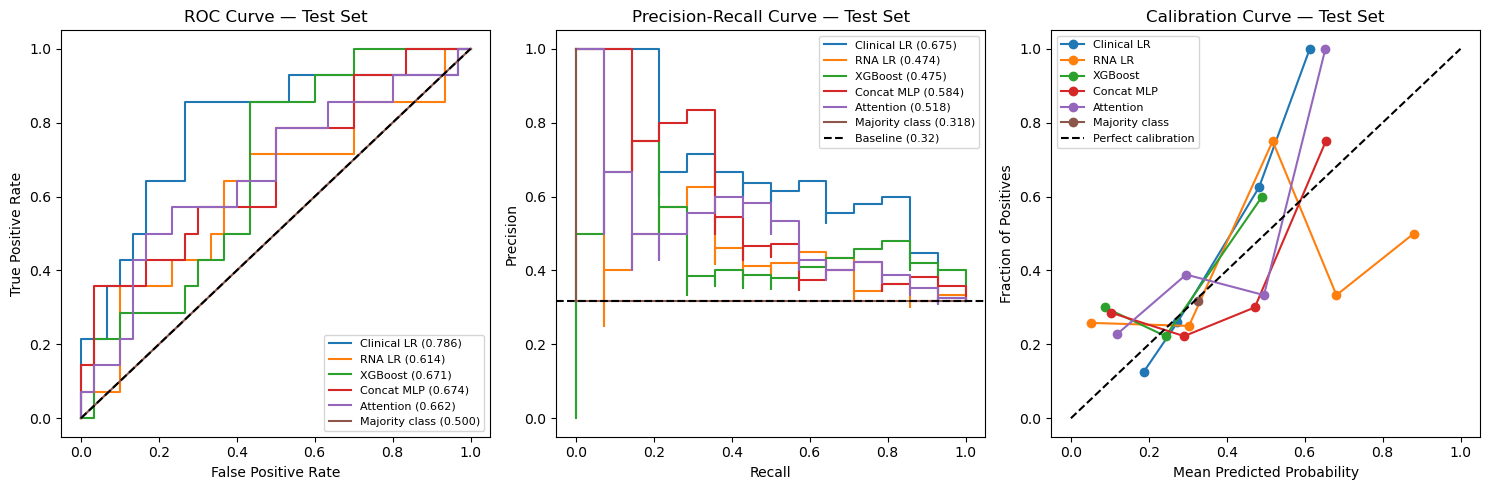

In [3]:
# ROC, precision-recall, and calibration curves for all models on the test set
models = {
    "Clinical LR": "y_pred_clin",
    "RNA LR":      "y_pred_rna",
    "XGBoost":     "y_pred_xgb",
    "Concat MLP":  "y_pred_concat",
    "Attention":   "y_pred_attn",
    "Majority class": "y_pred_majority",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for name, col in models.items():
    # ROC
    fpr, tpr, _ = roc_curve(test_df["y_true"], test_df[col])
    auc = roc_auc_score(test_df["y_true"], test_df[col])
    axes[0].plot(fpr, tpr, label=f"{name} ({auc:.3f})")

    # PR — steps-post makes the discrete nature of small-n curves explicit
    prec, rec, _ = precision_recall_curve(test_df["y_true"], test_df[col])
    ap = average_precision_score(test_df["y_true"], test_df[col])
    axes[1].plot(rec, prec, drawstyle="steps-post", label=f"{name} ({ap:.3f})")

    # Calibration
    frac_pos, mean_pred = calibration_curve(test_df["y_true"], test_df[col], n_bins=5)
    axes[2].plot(mean_pred, frac_pos, marker="o", label=name)

# ROC
axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — Test Set")
axes[0].legend(fontsize=8)

# PR — dashed baseline shows no-skill classifier performance
baseline = test_df["y_true"].mean()
axes[1].axhline(baseline, color="k", linestyle="--", label=f"Baseline ({baseline:.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve — Test Set")
axes[1].legend(fontsize=8)

# Calibration
axes[2].plot([0, 1], [0, 1], "k--", label="Perfect calibration")
axes[2].set_xlabel("Mean Predicted Probability")
axes[2].set_ylabel("Fraction of Positives")
axes[2].set_title("Calibration Curve — Test Set")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [4]:
# full model comparison metrics table across val and test
models = {
    "Majority class": "y_pred_majority",
    "Clinical LR":    "y_pred_clin",
    "RNA LR":         "y_pred_rna",
    "XGBoost":        "y_pred_xgb",
    "Concat MLP":     "y_pred_concat",
    "Attention":      "y_pred_attn",
}

metrics_df = pd.DataFrame([
    {
        "model":        name,
        "val_roc_auc":  round(roc_auc_score(val_df["y_true"],  val_df[col]), 3),
        "val_ap":       round(average_precision_score(val_df["y_true"],  val_df[col]), 3),
        "test_roc_auc": round(roc_auc_score(test_df["y_true"], test_df[col]), 3),
        "test_ap":      round(average_precision_score(test_df["y_true"], test_df[col]), 3),
    }
    for name, col in models.items()
])
display(metrics_df)

,model,val_roc_auc,val_ap,test_roc_auc,test_ap
0,Majority class,0.500,0.326,0.500,0.318
1,Clinical LR,0.884,0.826,0.786,0.675
2,RNA LR,0.719,0.582,0.614,0.474
3,XGBoost,0.786,0.687,0.671,0.475
4,Concat MLP,0.692,0.587,0.674,0.584
5,Attention,0.643,0.528,0.662,0.518


In [5]:
# inspect attention model predicted probability distribution
print(test_df["y_pred_attn"].describe())

count    44.000000
mean      0.228648
std       0.141379
min       0.030387
25%       0.119372
50%       0.200502
75%       0.321198
max       0.653258
Name: y_pred_attn, dtype: float64


### Interpretation
- Clinical LR is the strongest model, clinical features (stage, age, histology) are strong survival predictors and a simple model exploits them well with limited data.
- RNA LR and XGBoost add limited signal beyond clinical features alone at this sample size.
- Both deep learning models underperform. With 203 training samples, overfitting dominates regardless of architecture.
- Calibration curves are unreliable with n=44, too few samples per bin to draw firm conclusions.
- The attention model outputs a narrow probability range, visible as only two calibration points, a sign it has learned a near-constant prediction.

## 3. Risk stratification
   - Bin patients into high/mid/low risk tiers (top 20%, middle 60%, bottom 20%).
   - Plot Kaplan–Meier survival curves per tier for the best-performing model.
   - Perform log-rank test to assess statistical separation.

In [6]:
# risk tier event rates for all models on the test set
def risk_tier_summary(y_true, y_pred, model_name):
    high_thresh = np.percentile(y_pred, 80)
    low_thresh  = np.percentile(y_pred, 20)
    tiers = np.where(y_pred >= high_thresh, "High",
             np.where(y_pred <= low_thresh, "Low", "Mid"))
    return (
        pd.DataFrame({"y": y_true.values, "tier": tiers})
        .groupby("tier")["y"]
        .agg(n="count", events="sum", event_rate="mean")
        .reindex(["High", "Mid", "Low"])
        .assign(model=model_name)
    )

tier_df = pd.concat([
    risk_tier_summary(test_df["y_true"], test_df[col], name)
    for name, col in models.items()
]).reset_index()

print("Event rate by risk tier (test set)")
display(tier_df.pivot_table(index="model", columns="tier", values="event_rate").reindex(columns=["High", "Mid", "Low"]))

Event rate by risk tier (test set)


tier,High,Mid,Low
model,,,
Attention,0.555556,0.269231,0.222222
Clinical LR,0.666667,0.269231,0.111111
Concat MLP,0.555556,0.307692,0.111111
Majority class,0.318182,NaN,NaN
RNA LR,0.555556,0.269231,0.222222
XGBoost,0.444444,0.384615,0.000000


       n  events  median_days
tier                         
High   9       6       1556.0
Low    9       1       2632.0
Mid   26       7       2215.5


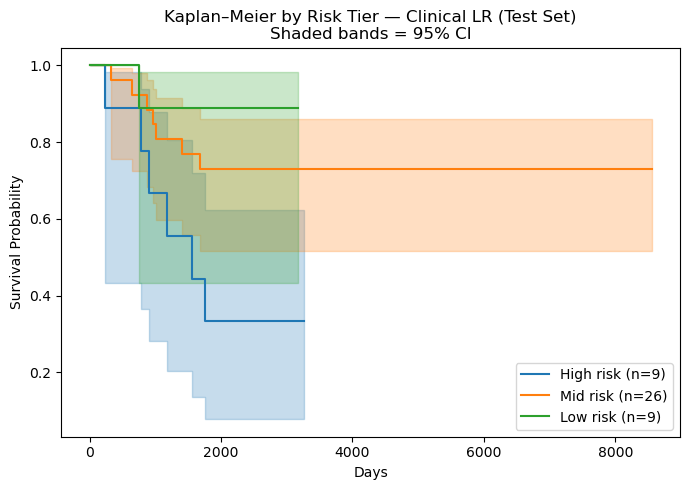


Log-rank test p-value: 0.0277


In [7]:
# Kaplan-Meier survival curves and log-rank test by risk tier
km_df = test_df[["sample", "y_pred_clin"]].merge(
    survival_df[["sample", "OS.time", "OS"]], on="sample", how="inner"
)

# bin into risk tiers using clinical LR predictions (best model)
high_thresh = km_df["y_pred_clin"].quantile(0.80)
low_thresh  = km_df["y_pred_clin"].quantile(0.20)
km_df["tier"] = km_df["y_pred_clin"].apply(
    lambda p: "High" if p >= high_thresh else ("Low" if p <= low_thresh else "Mid")
)

print(km_df.groupby("tier")[["OS", "OS.time"]].agg(n=("OS", "count"), events=("OS", "sum"), median_days=("OS.time", "median")))

# KM curves per tier
fig, ax = plt.subplots(figsize=(7, 5))
kmf = KaplanMeierFitter()
for tier in ["High", "Mid", "Low"]:
    mask = km_df["tier"] == tier
    kmf.fit(km_df.loc[mask, "OS.time"], km_df.loc[mask, "OS"], label=f"{tier} risk (n={mask.sum()})")
    kmf.plot_survival_function(ax=ax)

ax.set_xlabel("Days")
ax.set_ylabel("Survival Probability")
ax.set_title("Kaplan–Meier by Risk Tier — Clinical LR (Test Set)\nShaded bands = 95% CI")
plt.tight_layout()
plt.savefig("../reports/km_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# log-rank test across all three tiers
result = multivariate_logrank_test(km_df["OS.time"], km_df["tier"], km_df["OS"])
print(f"\nLog-rank test p-value: {result.p_value:.4f}")

### Interpretation
- The three risk tiers separate in the expected direction, high-risk patients have substantially worse survival than low-risk patients.
- Most events in the high-risk group occur within the first 2000 days, while the low-risk group remains near 90% survival throughout follow-up.
- The log-rank test is statistically significant (p = 0.028), suggesting the separation is unlikely due to chance alone.
- Confidence intervals are wide given only 9 patients per tier, the result is encouraging but should be interpreted cautiously at this sample size.
- Clinical LR achieves the best overall tier separation, 0.667 high-risk event rate vs 0.111 low-risk, a 6x difference.
- XGBoost identifies the cleanest low-risk group (0.000 events), the strongest individual result in the table, though its high-risk capture is lower than Clinical LR.
- Concat MLP matches Clinical LR on high-risk capture but fails to separate the low-risk group from mid-risk.
- Attention fusion shows almost no separation across tiers, consistent with its near-random test AUC.
- RNA LR sits in the middle throughout, it captures some signal but is consistently outperformed by clinical features alone.

## 4. Interpretability
   - XGBoost: SHAP feature importances on the test set.
   - Attention model: distribution of learned modality weights across test patients.

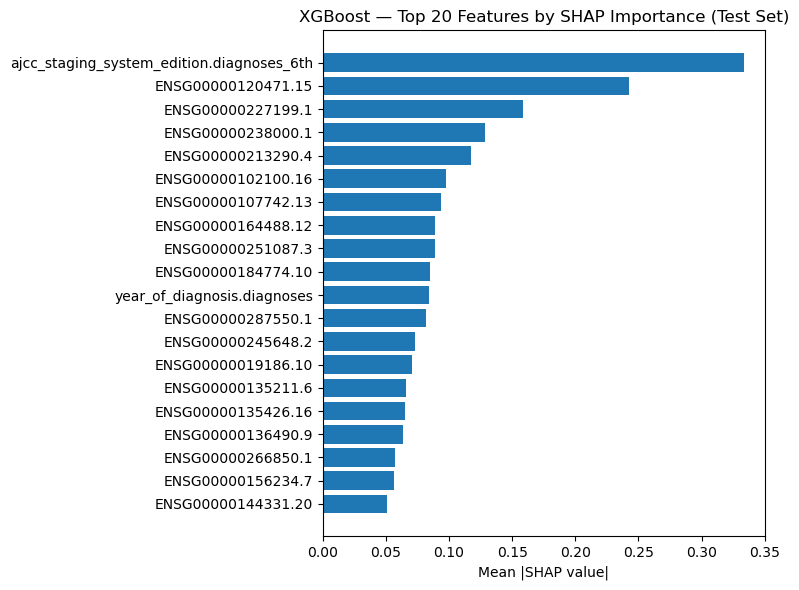

,feature,gene_symbol,mean_abs_shap
4708,ENSG00000120471.15,TP53AIP1,0.242504
17563,ENSG00000227199.1,ST7-AS1,0.158858
19216,ENSG00000238000.1,PSME2P1,0.128466
16291,ENSG00000213290.4,PGK1P2,0.117654
2511,ENSG00000102100.16,SLC35A2,0.097328
3250,ENSG00000107742.13,SPOCK2,0.093940
10152,ENSG00000164488.12,DACT2,0.088811
20366,ENSG00000251087.3,ALG1L3P,0.088635
13418,ENSG00000184774.10,MGAT4EP,0.085202
25406,ENSG00000287550.1,ENSG00000287550,0.082090


In [8]:
# XGBoost SHAP feature importances and attention modality weights
with open(models_dir / "xgboost/xgboost_model.pkl", "rb") as f:
    xgb_model = pickle.load(f)

X_test_concat_df = pd.read_parquet(assembled_dir / "test/X_concat.parquet")
X_test_concat_df.columns = X_test_concat_df.columns.str.replace(r"[\[\]<]", "_", regex=True)

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_concat_df)

shap_df = pd.DataFrame({
    "feature":       X_test_concat_df.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(shap_df["feature"][::-1], shap_df["mean_abs_shap"][::-1])
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("XGBoost — Top 20 Features by SHAP Importance (Test Set)")
plt.tight_layout()
plt.show()

# look up gene symbols for top RNA features via Ensembl REST API
rna_features = shap_df[shap_df["feature"].str.startswith("ENSG")].head(20)
ensembl_ids = rna_features["feature"].str.split(".").str[0].tolist()

response = requests.post(
    "https://rest.ensembl.org/lookup/id",
    headers={"Content-Type": "application/json", "Accept": "application/json"},
    json={"ids": ensembl_ids},
)
id_to_symbol = {k: v.get("display_name", k) for k, v in response.json().items()}

rna_features = rna_features.copy()
rna_features["gene_symbol"] = rna_features["feature"].str.split(".").str[0].map(id_to_symbol)
display(rna_features[["feature", "gene_symbol", "mean_abs_shap"]])


       RNA weight  Clinical weight
count        44.0             44.0
mean          1.0              0.0
std           0.0              0.0
min           1.0              0.0
25%           1.0              0.0
50%           1.0              0.0
75%           1.0              0.0
max           1.0              0.0


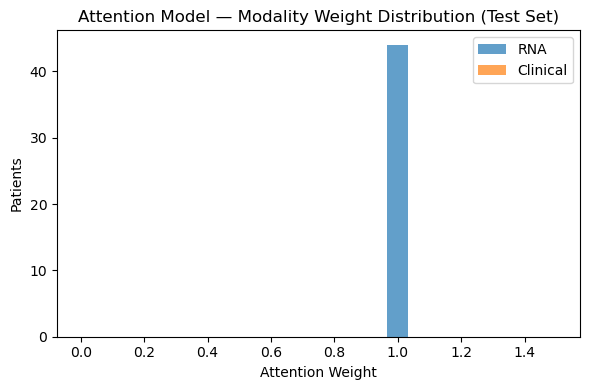

In [9]:
# attention model modality weight distribution

# Attention model: extract per-patient modality weights
with open(models_dir / "multimodal/attn_model.pkl", "rb") as f:
    attn_model = pickle.load(f)

X_rna_test_df  = pd.read_parquet(assembled_dir / "test/X_rna.parquet")
X_clin_test_df = pd.read_parquet(assembled_dir / "test/X_clinical.parquet")
rna_t  = torch.tensor(X_rna_test_df.values,  dtype=torch.float32)
clin_t = torch.tensor(X_clin_test_df.values, dtype=torch.float32)

# replicate the forward pass to extract attention weights before weighted sum
attn_model.eval()
with torch.no_grad():
    rna_emb  = attn_model.rna_encoder(rna_t)
    clin_emb = attn_model.clin_proj(attn_model.clin_encoder(clin_t))
    stacked  = torch.stack([rna_emb, clin_emb], dim=1)
    weights  = torch.softmax(attn_model.attention(stacked), dim=1).squeeze(-1).cpu().numpy()

weights_df = pd.DataFrame(weights, columns=["RNA weight", "Clinical weight"])
print(weights_df.describe().round(3))

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(weights_df["RNA weight"],      bins=15, alpha=0.7, label="RNA")
ax.hist(weights_df["Clinical weight"], bins=15, alpha=0.7, label="Clinical")
ax.set_xlabel("Attention Weight")
ax.set_ylabel("Patients")
ax.set_title("Attention Model — Modality Weight Distribution (Test Set)")
ax.legend()
plt.tight_layout()
plt.show()


In [10]:
# inspect raw attention scores before softmax
with torch.no_grad():
    raw_scores = attn_model.attention(stacked).squeeze(-1).cpu().numpy()
    print(pd.DataFrame(raw_scores, columns=["RNA score", "Clinical score"]).describe())


       RNA score  Clinical score
count  44.000000       44.000000
mean    1.532242      -90.933273
std     3.287325       25.459633
min    -6.063346     -186.855026
25%    -0.134387      -93.121120
50%     1.329392      -83.276249
75%     4.219736      -75.261688
max     7.980142      -65.776360


### Interpretation

**XGBoost SHAP**
- The top clinical predictor is `ajcc_staging_system_edition_6th`, likely a proxy for diagnosis era rather than tumor biology.  `year_of_diagnosis` also ranks in the top 10, reinforcing this.
- Top RNA features include TP53AIP1 (a p53 apoptosis target), RBBP8-AS1 (antisense to a BRCA1-interacting repair gene), and CYP24A1 (vitamin D metabolism), all biologically plausible survival predictors.
- Several top features are pseudogenes or uncharacterized RNAs, likely noise at this sample size.

**Attention model**
- The attention mechanism collapsed to a degenerate solution: RNA weight = 1.0 and clinical weight = 0.0 for all 44 test patients.
- Raw attention scores reveal the clinical encoder outputs embeddings with extreme negative magnitude (mean score -69 vs RNA mean +2), causing softmax to saturate.
- This indicates the attention layer failed to learn meaningful per-patient modality weighting, a known failure mode when fitting complex architectures on small datasets.

## 5. Final model selection

**Final model recommendation: Clinical Logistic Regression**

Clinical LR is the clear choice across every evaluation dimension:

- Discrimination: highest ROC-AUC and AP on both val and test sets
- Risk stratification: well-separated KM curves with a significant log-rank test (p = 0.028)
- Interpretability: coefficients map directly to clinical factors oncologists already use
- Deployment: no preprocessing pipeline beyond standard scaling, trivial to serve

XGBoost is a reasonable fallback if nonlinear feature interactions matter, but shows no meaningful performance gain here and is harder to explain clinically.

The deep learning models are not competitive at this sample size:
- Both overfit severely with 203 training samples
- The attention mechanism collapsed to ignoring clinical features entirely
- Included as architectural demonstrations, not as deployable models

For datasets of this size, simplicity is a feature. A logistic regression on stage, age, and histology is transparent, fast, and robust.  These qualities that outweigh marginal AUC gains from more complex models.